# 1.7) Matplotlib and xarray

This subchapter pairs the two tools that turn arrays into understanding: matplotlib, which draws figures from raw arrays, and xarray, which wraps arrays in named dimensions, coordinates, and metadata so that operations read in the language of the data. We work with one synthetic dataset throughout — a year of daily 2 m air temperature on a small latitude–longitude grid — and close with a generated-code plotting bug that silently flips a map upside down.

:::{admonition} Learning objectives
:class: tip
- Build figures with the figure/axes model: line, scatter, histogram, and 2D plots with colorbars and labelled axes.
- Save publication-quality vector figures.
- Distinguish a DataArray from a Dataset, and read its dims, coords, and attrs.
- Select by position (.isel) and by label (.sel), and do label-aware arithmetic and reductions over named dimensions.
- Re-bin time with .resample and aggregate with .groupby, and plot directly with .plot().
- Round-trip data through netCDF with to_netcdf and open_dataset.
:::

## The figure and axes model

matplotlib draws onto an *axes* (a single plot with its x- and y-axis) that lives inside a *figure*. The explicit pattern — create `fig, ax`, call methods on `ax`, label everything — scales cleanly from one panel to many. Always label axes with their physical quantity and SI unit.

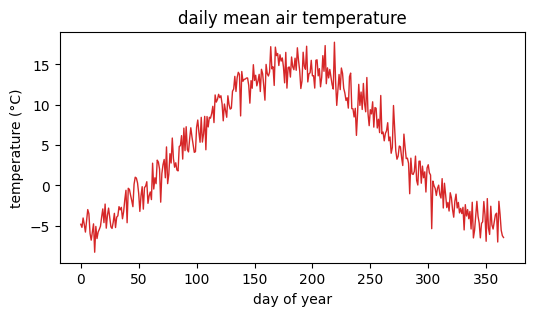

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
days = np.arange(366)
seasonal = -np.cos(2 * np.pi * days / 366) * 10.0
ts_celsius = 5.0 + seasonal + rng.normal(0, 1.5, size=366)   # daily spatial-mean temp (°C)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(days, ts_celsius, color="tab:red", linewidth=1)
ax.set_xlabel("day of year")
ax.set_ylabel("temperature (°C)")
ax.set_title("daily mean air temperature")
plt.show()

## Subplots, scatter, and histograms

`plt.subplots(nrows, ncols)` returns a grid of axes. Scatter plots show paired values; histograms show a distribution.

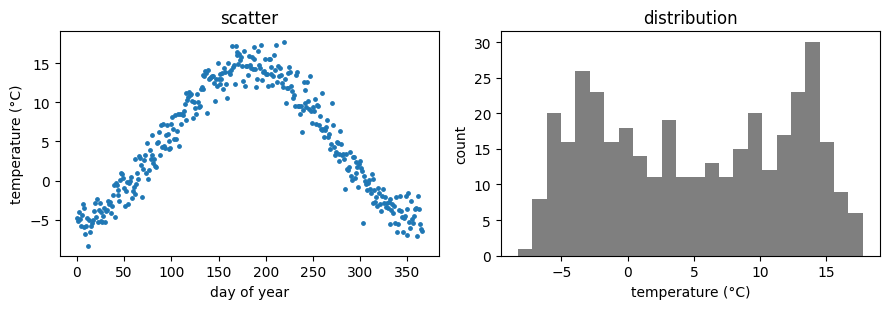

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

axes[0].scatter(days, ts_celsius, s=6, color="tab:blue")
axes[0].set_xlabel("day of year")
axes[0].set_ylabel("temperature (°C)")
axes[0].set_title("scatter")

axes[1].hist(ts_celsius, bins=24, color="tab:gray")
axes[1].set_xlabel("temperature (°C)")
axes[1].set_ylabel("count")
axes[1].set_title("distribution")

plt.tight_layout()
plt.show()

## Two-dimensional fields: pcolormesh, contourf, and colorbars

For a field on a grid, `pcolormesh` draws filled cells and `contourf` draws filled contours; both accept the x- and y-coordinates, which keeps the axes physically meaningful. A colorbar maps colour to value and must be labelled with its unit.

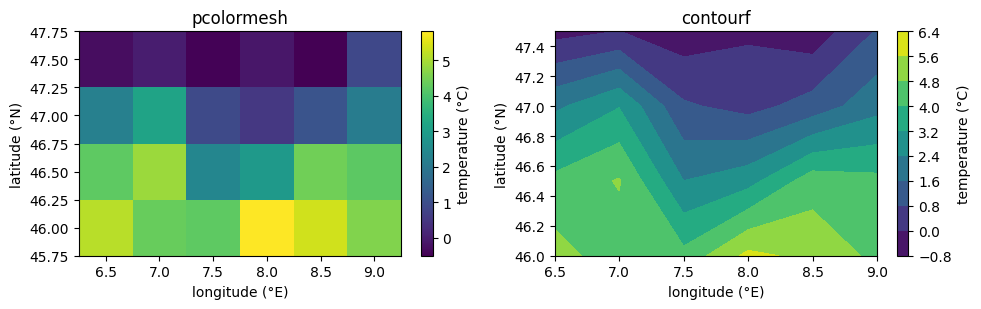

In [3]:
lat = np.array([46.0, 46.5, 47.0, 47.5])   # ascending: south -> north
lon = np.array([6.5, 7.0, 7.5, 8.0, 8.5, 9.0])
field_celsius = 5.0 + (46.0 - lat)[:, None] * 3.0 + rng.normal(0, 1.0, size=(4, 6))  # colder north

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

pcm = axes[0].pcolormesh(lon, lat, field_celsius, shading="auto")
fig.colorbar(pcm, ax=axes[0], label="temperature (°C)")
axes[0].set_title("pcolormesh")
axes[0].set_xlabel("longitude (°E)")
axes[0].set_ylabel("latitude (°N)")

cf = axes[1].contourf(lon, lat, field_celsius, levels=8)
fig.colorbar(cf, ax=axes[1], label="temperature (°C)")
axes[1].set_title("contourf")
axes[1].set_xlabel("longitude (°E)")
axes[1].set_ylabel("latitude (°N)")

plt.tight_layout()
plt.show()

## Saving vector figures

Save to a vector format (svg, pdf) for figures that must stay sharp at any zoom; save to png only for raster previews.

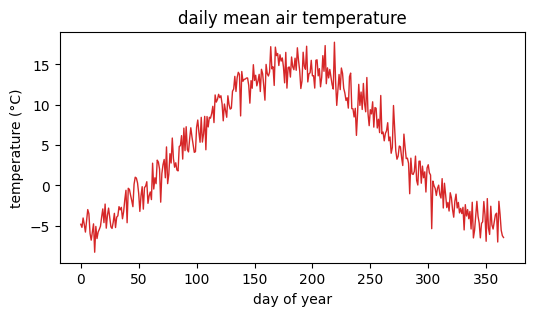

['temperature_timeseries.pdf', 'temperature_timeseries.svg']


In [4]:
from pathlib import Path

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(days, ts_celsius, color="tab:red", linewidth=1)
ax.set_xlabel("day of year")
ax.set_ylabel("temperature (°C)")
ax.set_title("daily mean air temperature")
fig.savefig("temperature_timeseries.svg")   # vector
fig.savefig("temperature_timeseries.pdf")   # vector
plt.show()

print(sorted(p.name for p in Path(".").glob("temperature_timeseries.*")))

## When generated code lies: a flipped map

ai assistants reach for `imshow` to display a 2D array. By default `imshow` draws array row 0 at the *top* of the figure (`origin='upper'`). Our latitude coordinate is ascending (row 0 is the southernmost), so the map comes out upside down — north and south swapped — with no error and a perfectly plausible-looking picture.

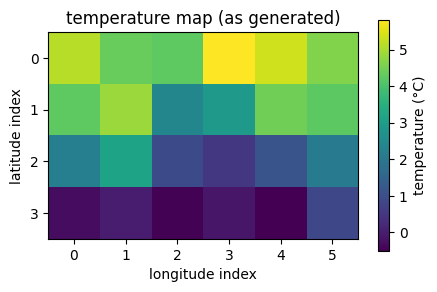

In [5]:
# the "temperature map" as an assistant might generate it
fig, ax = plt.subplots(figsize=(5, 3))
im = ax.imshow(field_celsius)
fig.colorbar(im, ax=ax, label="temperature (°C)")
ax.set_title("temperature map (as generated)")
ax.set_xlabel("longitude index")
ax.set_ylabel("latitude index")
plt.show()

:::{admonition} Diagnosis: imshow ignores the coordinates and inverts the latitude axis
:class: warning
`imshow` plots by array position, not by coordinate, and its default `origin='upper'` puts row 0 (the southernmost latitude) at the top — so the warm southern band appears where the cold north should be. The numbers are correct; the geography is upside down, and nothing signals it. The fix is to plot with the coordinates: `pcolormesh(lon, lat, field)`, or, if you must use imshow, pass `origin='lower'` and an `extent`. The comparison below makes the flip visible.
:::

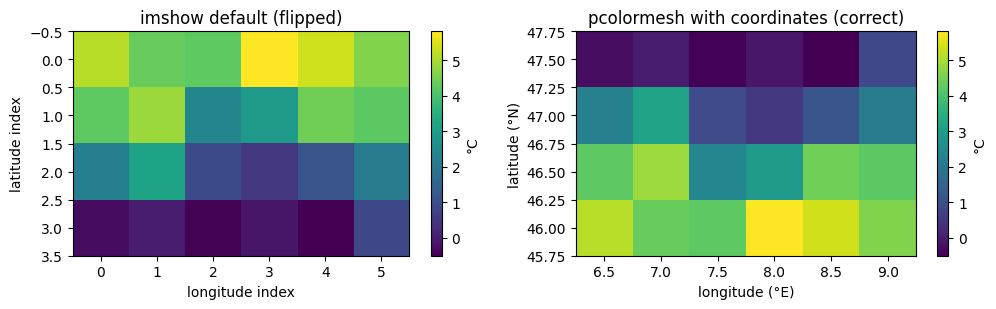

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

# left: imshow default -> row 0 (south) drawn at the top, latitude inverted
im0 = axes[0].imshow(field_celsius)
fig.colorbar(im0, ax=axes[0], label="°C")
axes[0].set_title("imshow default (flipped)")
axes[0].set_xlabel("longitude index")
axes[0].set_ylabel("latitude index")

# right: pcolormesh with coordinates -> latitude axis correct (north at top)
pcm = axes[1].pcolormesh(lon, lat, field_celsius, shading="auto")
fig.colorbar(pcm, ax=axes[1], label="°C")
axes[1].set_title("pcolormesh with coordinates (correct)")
axes[1].set_xlabel("longitude (°E)")
axes[1].set_ylabel("latitude (°N)")

plt.tight_layout()
plt.show()

## xarray: arrays that carry their labels

xarray attaches names and coordinates to numpy arrays. A `DataArray` is a single labelled array; a `Dataset` is a dict-like collection of DataArrays sharing coordinates. Operations then refer to dimensions by name (`dim="time"`) instead of by axis number.

In [7]:
import xarray as xr

rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2025-01-01", dtype="datetime64[D]")   # 366 days (leap year)
lat = np.array([46.0, 46.5, 47.0, 47.5])
lon = np.array([6.5, 7.0, 7.5, 8.0, 8.5, 9.0])

n_time = time.size
doy = np.arange(n_time)
seasonal = -np.cos(2 * np.pi * doy / n_time) * 10.0      # seasonal cycle
lat_effect = (46.0 - lat) * 3.0                          # colder toward the north
temp = (5.0 + seasonal[:, None, None] + lat_effect[None, :, None]
        + rng.normal(0, 1.5, size=(n_time, 4, 6)))

ds = xr.Dataset(
    {"t2m": (("time", "lat", "lon"), temp)},
    coords={"time": time, "lat": lat, "lon": lon},
)
ds["t2m"].attrs.update(units="degC", long_name="2 m air temperature")
ds["lat"].attrs["units"] = "degrees_north"
ds["lon"].attrs["units"] = "degrees_east"
print(ds)

<xarray.Dataset> Size: 73kB
Dimensions:  (time: 366, lat: 4, lon: 6)
Coordinates:
  * time     (time) datetime64[s] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
  * lat      (lat) float64 32B 46.0 46.5 47.0 47.5
  * lon      (lon) float64 48B 6.5 7.0 7.5 8.0 8.5 9.0
Data variables:
    t2m      (time, lat, lon) float64 70kB -4.811 -5.198 ... -6.743 -12.78


:::{admonition} Computational-thinking fundamental: refer to data by label, not by position
:class: important
A numpy axis number (`axis=0`) only means something if you remember the array's dimension order; rearrange the array and the same code silently does the wrong thing. xarray removes that fragility: `mean(dim="time")` averages over time no matter where the time axis sits. Naming dimensions and coordinates makes the intent explicit and the code robust to changes in layout — the same reasoning that motivates encoding units in variable names.
:::

In [8]:
# selecting a variable from a Dataset returns a DataArray
da = ds["t2m"]
print(type(ds).__name__, "->", type(da).__name__)
print("dims:", da.dims)
print("shape:", da.shape)
print("units:", da.attrs["units"])

Dataset -> DataArray
dims: ('time', 'lat', 'lon')
shape: (366, 4, 6)
units: degC


In [9]:
# .isel selects by integer position; .sel selects by coordinate label
print("isel(time=0) shape:", ds["t2m"].isel(time=0).shape)       # one day, drops time

day = ds["t2m"].sel(time="2024-07-15")                           # by label
print("2024-07-15 spatial mean:", day.mean().round(2).item(), "°C")

# nearest-label selection
print("nearest lat to 46.7:", ds["lat"].sel(lat=46.7, method="nearest").item())

isel(time=0) shape: (4, 6)
2024-07-15 spatial mean: 12.64 °C
nearest lat to 46.7: 46.5


In [10]:
# reductions name the dimension; label-aware arithmetic aligns by coordinate
domain_mean = ds["t2m"].mean(dim=("lat", "lon"))   # -> time series
clim_field = ds["t2m"].mean(dim="time")            # -> lat x lon field
print("domain_mean dims:", domain_mean.dims, "| clim_field dims:", clim_field.dims)

anomaly = ds["t2m"] - ds["t2m"].mean(dim="time")
print("anomaly dims:", anomaly.dims, "| mean anomaly:", anomaly.mean().round(3).item())

domain_mean dims: ('time',) | clim_field dims: ('lat', 'lon')
anomaly dims: ('time', 'lat', 'lon') | mean anomaly: 0.0


In [11]:
# resample re-bins time; groupby aggregates by a derived label (calendar month)
monthly = ds["t2m"].resample(time="MS").mean()
print("monthly time steps:", monthly["time"].size)

clim_by_month = ds["t2m"].groupby("time.month").mean()
warmest_month = int(clim_by_month.mean(dim=("lat", "lon")).argmax("month").item()) + 1
print("months:", clim_by_month["month"].values)
print("warmest climatological month:", warmest_month)

monthly time steps: 12
months: [ 1  2  3  4  5  6  7  8  9 10 11 12]
warmest climatological month: 7


xarray's `.plot()` reads coordinates, labels, and units straight from the metadata: a 1D array becomes a line, a 2D array a `pcolormesh`, both labelled automatically.

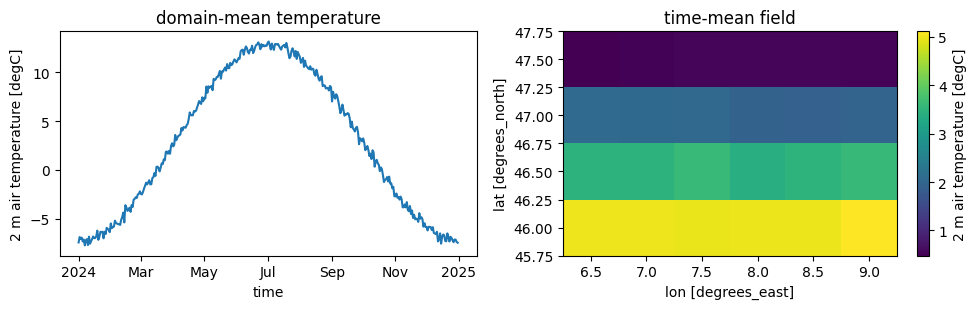

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
ds["t2m"].mean(dim=("lat", "lon")).plot(ax=axes[0])   # 1D -> line
ds["t2m"].mean(dim="time").plot(ax=axes[1])           # 2D -> pcolormesh
axes[0].set_title("domain-mean temperature")
axes[1].set_title("time-mean field")
plt.tight_layout()
plt.show()

:::{admonition} Quick exercise: a single-point monthly series
:class: note
Select the grid cell at 47.5° N, 7.5° E, then compute its monthly-mean temperature with `resample`. Print how many monthly values result.
:::

:::{admonition} Solution
:class: note dropdown
```python
point = ds["t2m"].sel(lat=47.5, lon=7.5)
monthly_point = point.resample(time="MS").mean()
print(monthly_point["time"].size)
```
:::

In [13]:
# xarray reads and writes netCDF, preserving coordinates and attributes
ds.to_netcdf("air_temperature.nc")
reopened = xr.open_dataset("air_temperature.nc")
print(list(reopened.data_vars), "| units:", reopened["t2m"].attrs["units"])
reopened.close()

['t2m'] | units: degC


:::{admonition} Going deeper: maps with cartopy
:class: seealso dropdown
For real maps, give the axes a projection and add geographic context. xarray's `.plot()` accepts the axes.

```python
import cartopy.crs as ccrs
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ds["t2m"].mean("time").plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()
```

`transform` tells cartopy the coordinate system of the data; the projection is the one you draw in.
:::

:::{admonition} Going deeper: lazy loading with dask
:class: seealso dropdown
Opening a dataset with `chunks` defers computation: operations build a task graph, and nothing runs until `.compute()` (or a plot, or a save).

```python
ds = xr.open_dataset("big.nc", chunks={"time": 100})
result = ds["t2m"].mean("time")   # lazy: not yet computed
result.compute()                  # runs the graph, chunk by chunk
```

This is how xarray scales to datasets far larger than memory.
:::

:::{admonition} Going deeper: cloud-native data with zarr (ARCO-ERA5)
:class: seealso dropdown
Analysis-ready, cloud-optimised datasets such as ARCO-ERA5 are stored as zarr and opened directly over the network, then sliced lazily before anything is downloaded.

```python
store = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
era5 = xr.open_zarr(store, chunks={"time": 48})
t2m = era5["2m_temperature"].sel(time="2020-01-01")   # lazy slice
```

This requires network access and the zarr and gcsfs packages, so it is shown for reference and not run in this book.
:::

:::{admonition} Takeaways
:class: danger
- Build plots explicitly with `fig, ax = plt.subplots(...)`, label every axis with its unit, and add a labelled colorbar to 2D plots.
- Use `pcolormesh`/`contourf` with coordinates for fields; `imshow` plots by array position and flips an ascending latitude axis by default.
- Save vector formats (svg, pdf) for figures that must stay sharp.
- A DataArray is one labelled array; a Dataset is a collection sharing coordinates; both carry dims, coords, and attrs.
- Select by label with `.sel` and by position with `.isel`; reduce over named dims (`mean(dim="time")`), not axis numbers.
- `.resample` re-bins time and `.groupby` aggregates by a derived label; `to_netcdf`/`open_dataset` round-trip data with its metadata intact.
:::

## Resources

- [Pythia Foundations — Matplotlib Basics](https://foundations.projectpythia.org/core/matplotlib/matplotlib-basics/) — the figure/axes model and the core plot types used here.
- [Pythia Foundations — Introduction to Xarray](https://foundations.projectpythia.org/core/xarray/xarray-intro/) — DataArray/Dataset, label-based selection, and built-in plotting.
- [An Introduction to Earth and Environmental Data Science](https://earth-env-data-science.github.io/) — Abernathey and Key; integrates numpy, matplotlib, and xarray on real geoscience data.
:::